In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv("Sms Spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label', 'text']

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())

df.head()

Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

print(df.head())
print(encoder.classes_)

   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
['ham' 'spam']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [5]:
MAX_WORDS = 5000
MAX_LEN = 50
EMBEDDING_DIM = 64

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post'
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (4457, 50)
Testing shape: (1115, 50)


In [6]:
model = Sequential([
    Input(shape=(MAX_LEN,)),
    
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM
    ),
    
    GRU(
        units=64,
        dropout=0.2,
        recurrent_dropout=0.2
    ),
    
    Dense(32, activation='relu'),
    
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 50, 64)              │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,073 (1.32 MB)

 Trainable params: 347,073 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8715 - loss: 0.4181 - val_accuracy: 0.8430 - val_loss: 0.4387
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8715 - loss: 0.3979 - val_accuracy: 0.8430 - val_loss: 0.4377
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8715 - loss: 0.3696 - val_accuracy: 0.8430 - val_loss: 0.2342
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9801 - loss: 0.0740 - val_accuracy: 0.9765 - val_loss: 0.0755
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9905 - loss: 0.0359 - val_accuracy: 0.9776 - val_loss: 0.0709
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9961 - loss: 0.0192 - val_accuracy: 0.9798 - val_loss: 0.0765
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9983 - loss: 0.0118 - val_accuracy: 0.9809 - val_loss: 0.0835
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9989 - loss: 0.0064 - val_accu

In [8]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9839 - loss: 0.0568
Test Loss: 0.05675707012414932
Test Accuracy: 0.9838564991950989


In [9]:
y_pred_prob = model.predict(X_test_pad)

y_pred = (y_pred_prob >= 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.95      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[958   8]
 [ 10 139]]


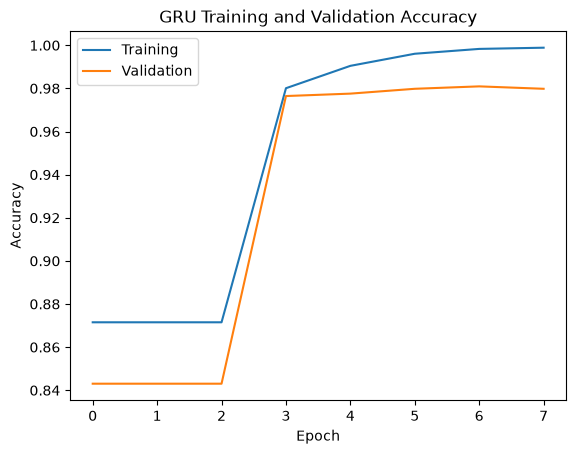

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('GRU Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training', 'Validation'])

plt.show()

In [12]:
def predict_sms(message):
    sequence = tokenizer.texts_to_sequences([message])
    
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post'
    )
    
    prediction = model.predict(padded)[0][0]
    
    if prediction >= 0.5:
        print("Spam")
        print("Probability:", prediction)
    else:
        print("Ham")
        print("Probability:", 1 - prediction)

In [13]:
predict_sms("Congratulations! You have won a big prize money. Call now!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Spam
Probability: 0.9812668


In [14]:
predict_sms("Hey, are you going to play cricket?")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Ham
Probability: 0.9975441
